# LightGlue Demo

This notebook demonstrates how you can install and use LightGlue, a 2023 library for feature point matching. Check their GitHub page for more details and a link to the paper: https://github.com/cvg/LightGlue

This Demo uses the SuperPoint detector from the paper that you read for your Assessment 1. LightGlue also comes with an implementation of DISK, another learned detector. You can use LightGlue with other descriptors too, e.g. SIFT.

Besides using LightGlue, this notebook also demonstrates how you can quite easily install and use any other library that is available via pip / git on the Jupyter server.

### Install LightGlue

In [9]:
from pathlib import Path
import time

# First try to import LightGlue from the current Python environment.
try:
    from lightglue import LightGlue, SuperPoint, DISK
    from lightglue.utils import load_image, rbd
    from lightglue import viz2d
except ImportError:
    # Install LightGlue only when it is not already available.
    %pip install --progress-bar off --quiet git+https://github.com/cvg/LightGlue.git
    from lightglue import LightGlue, SuperPoint, DISK
    from lightglue.utils import load_image, rbd
    from lightglue import viz2d

import torch
torch.set_grad_enabled(False);

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # 'mps', 'cpu'

### Get Access to the Kitti Dataset

In [10]:
import sys

# Add the course support directory to Python's module search path.
support_dir = Path.cwd().resolve().parents[1] / "support"
if str(support_dir) not in sys.path:
    sys.path.insert(0, str(support_dir))

# Import our KITTI helper and load the sequence used in this practical.
import kitti_utils as kitti
sequence = kitti.load_kitti_dataset("2011_09_26_drive_0035")

### Extract SuperPoints and use LightGlue to match them

Keypoint Detection time: 0.049252 seconds
Matcher time: 0.035665 seconds
matches:  918


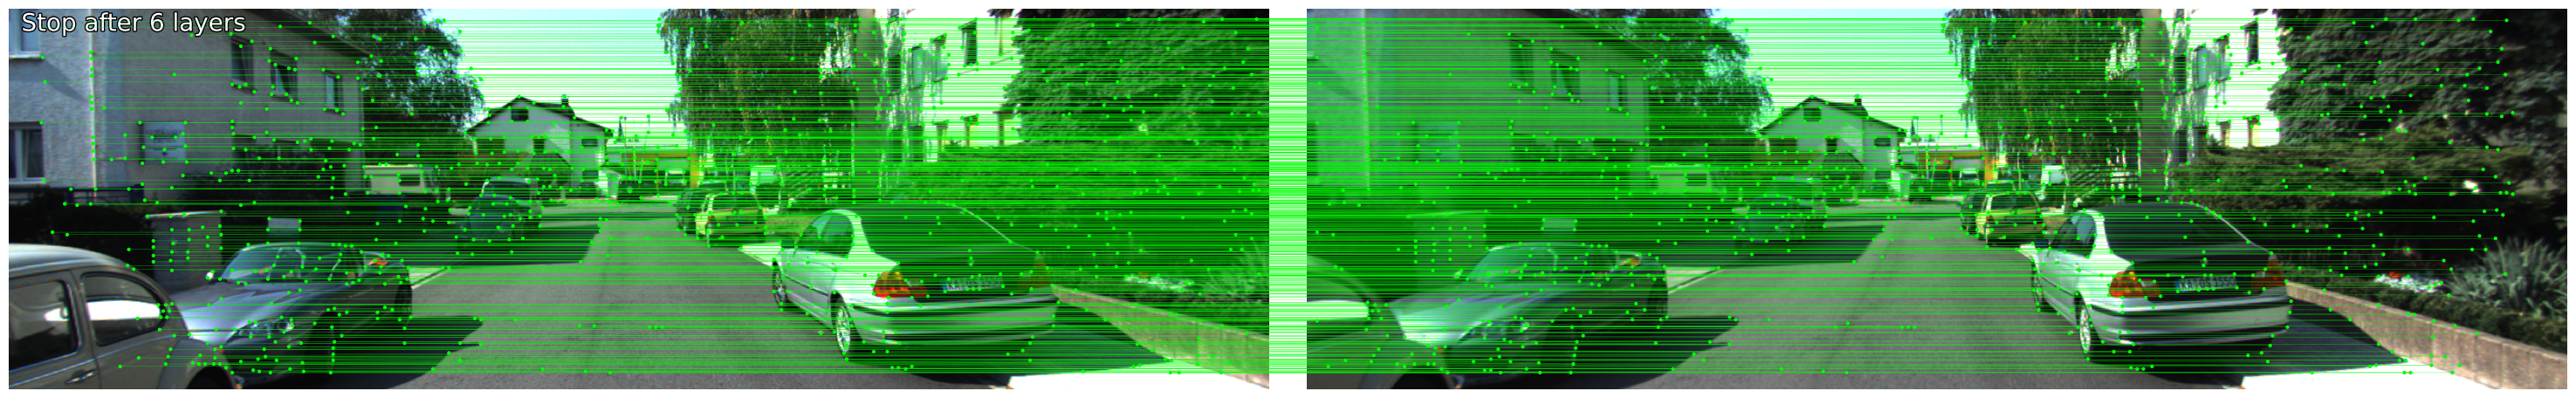

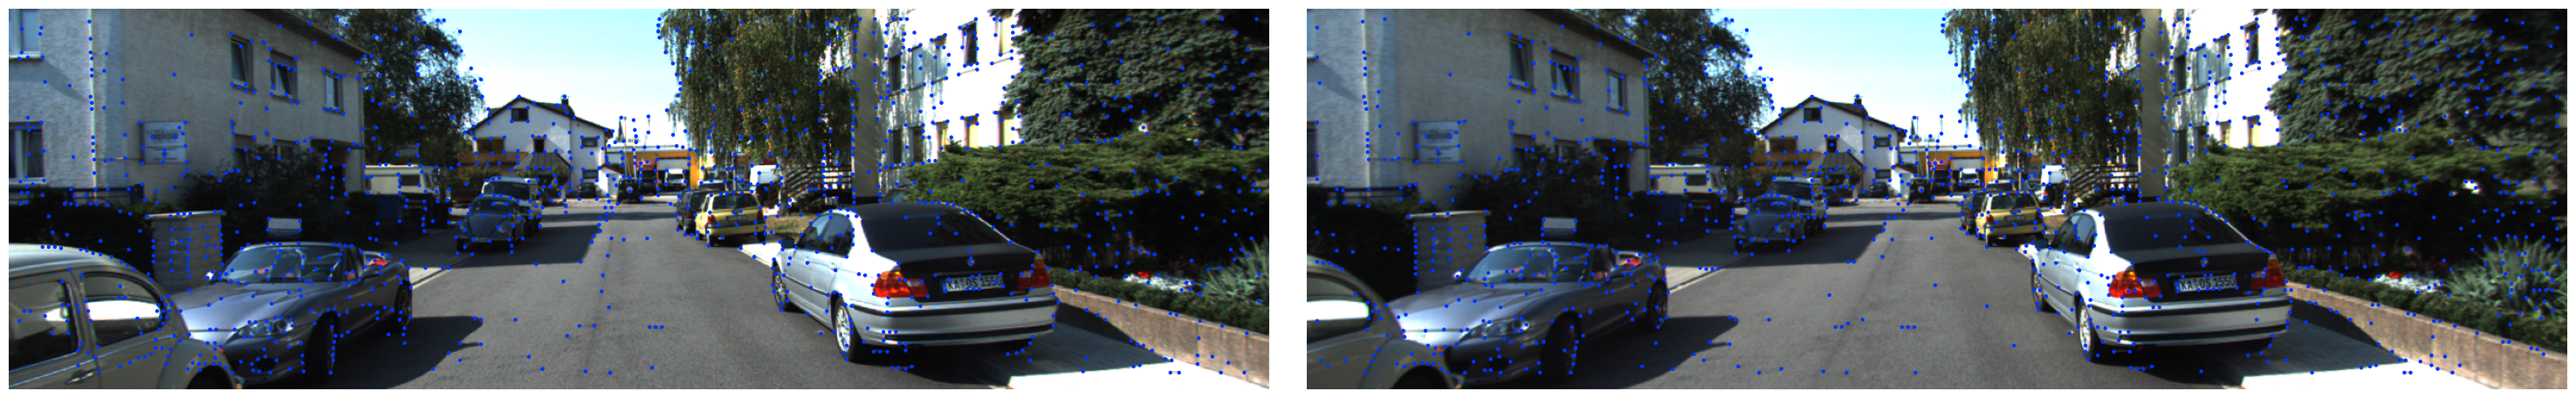

In [12]:

# we will use SuperPoint as the feature extractor
extractor = SuperPoint(max_num_keypoints=2048).eval().to(device)  # load the extractor
matcher = LightGlue(features='superpoint').eval().to(device)


# Read the left and right camera images from frame 10.
image0, image1 = sequence.stereo(10)

# Convert each NumPy image from H x W x C to a PyTorch C x H x W tensor.
# Dividing by 255 changes the pixel range from 0...255 to 0...1.
image0 = torch.from_numpy(image0.copy()).permute(2, 0, 1).float() / 255
image1 = torch.from_numpy(image1.copy()).permute(2, 0, 1).float() / 255

# extract features and match them
start_time = time.perf_counter()
feats0 = extractor.extract(image0.to(device))
feats1 = extractor.extract(image1.to(device))
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Keypoint Detection time: {elapsed_time:.6f} seconds")


start_time = time.perf_counter()
matches01 = matcher({'image0': feats0, 'image1': feats1})
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Matcher time: {elapsed_time:.6f} seconds")
feats0, feats1, matches01 = [rbd(x) for x in [feats0, feats1, matches01]]  # remove batch dimension
print('matches: ', (len(matches01['matches'])))

kpts0, kpts1, matches = feats0['keypoints'], feats1['keypoints'], matches01['matches']
m_kpts0, m_kpts1 = kpts0[matches[..., 0]], kpts1[matches[..., 1]]

# visualise the matches
axes = viz2d.plot_images([image0, image1])
viz2d.plot_matches(m_kpts0, m_kpts1, color='lime', lw=0.2)
viz2d.add_text(0, f'Stop after {matches01["stop"]} layers', fs=20)

kpc0, kpc1 = viz2d.cm_prune(matches01['prune0']), viz2d.cm_prune(matches01['prune1'])
viz2d.plot_images([image0, image1])
viz2d.plot_keypoints([kpts0, kpts1], colors=[kpc0, kpc1], ps=10)